In [2]:
import requests
import pandas as pd
from nba_api.stats.endpoints import teamyearbyyearstats
from nba_api.stats.static import teams
from nba_api.stats.endpoints import teamgamelogs
from nba_api.stats.endpoints import leaguegamelog
from nba_api.stats.endpoints import TeamYearByYearStats
from nba_api.stats.endpoints import BoxScoreAdvancedV3
from nba_api.stats.endpoints import BoxScoreTraditionalV3
from nba_api.stats.endpoints import TeamEstimatedMetrics
from nba_api.stats.static import teams
from nba_api.stats.endpoints import LeagueDashTeamStats
from calendar import monthrange
from nba_api.stats.endpoints import LeagueGameFinder
from nba_api.stats.endpoints import PlayerDashboardByTeamPerformance
from datetime import datetime, date, timedelta
from nba_api.stats.endpoints import TeamPlayerDashboard
from nba_api.stats.static.teams import get_teams
from nba_api.stats.endpoints import TeamPlayerOnOffDetails
import time

In [ ]:
df = pd.read_csv("./data/2022-23.csv", index_col = 0)

In [3]:
df = pd.read_csv("./data/old_format/2010-11.csv", index_col = 0)

<AxesSubplot: >

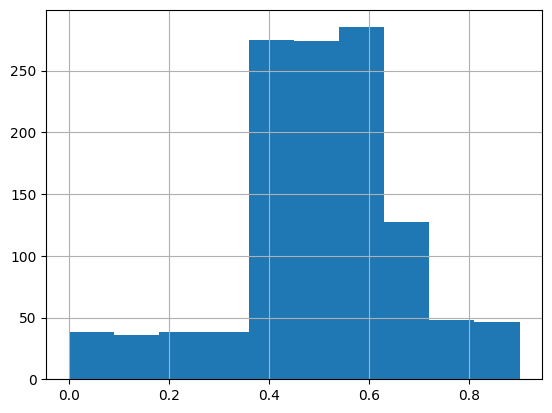

In [7]:
df["LAST_10_W_PCT"].hist()

In [68]:
last_10 = LeagueDashTeamStats(
    last_n_games=15,
    measure_type_detailed_defense="Base",
    date_from_nullable="01/03/2022",
    per_mode_detailed="PerGame",
    season="2021-22",
).get_data_frames()[0]

In [69]:
last_10

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,15,10,5,0.667,48.0,42.6,90.5,0.471,...,14,16,1,4,23,16,15,11,9,8
1,1610612738,Boston Celtics,15,11,4,0.733,48.3,44.3,87.2,0.508,...,9,5,9,18,12,16,8,14,3,1
2,1610612751,Brooklyn Nets,15,10,5,0.667,48.3,44.1,87.9,0.501,...,8,8,26,13,3,13,25,7,7,4
3,1610612766,Charlotte Hornets,15,11,4,0.733,48.0,45.4,88.6,0.512,...,23,1,9,9,6,4,15,21,4,7
4,1610612741,Chicago Bulls,15,5,10,0.333,48.3,40.1,86.3,0.465,...,29,28,5,20,29,24,12,16,28,28
5,1610612739,Cleveland Cavaliers,15,6,9,0.400,48.7,41.0,85.1,0.482,...,19,17,6,21,23,20,12,7,18,20
6,1610612742,Dallas Mavericks,15,11,4,0.733,48.0,40.3,82.3,0.489,...,19,27,9,30,28,3,11,19,16,10
7,1610612743,Denver Nuggets,15,8,7,0.533,48.7,44.3,86.0,0.516,...,15,2,26,25,25,23,25,11,5,18
8,1610612765,Detroit Pistons,15,5,10,0.333,48.0,39.9,88.1,0.453,...,17,14,18,9,7,28,27,20,23,21
9,1610612744,Golden State Warriors,15,8,7,0.533,48.0,40.0,85.3,0.469,...,4,11,25,26,21,1,29,26,24,16


In [6]:
teams = get_teams()
teams

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970},
 {'id': 1610612740,
  'full_name': 'New Orleans Pelicans',
  'abbreviation': 'NOP',
  'nickname': 'Pelicans',
  'city': 'New Orleans',
  'state': 'Louisiana',
  'year_founded': 2002},
 {'id': 1610612741,
  'full_name': 'Chicago Bulls',
  'abbreviation': 'CHI',
  'nickname': 'Bulls',
  'city': 'Chicago',
  'state': 'Illinois',
  'year_founded': 1966},
 {'id': 1610612742,
  'full_name': 'Dallas Mavericks',
  'abbreviation': 'DAL',
  'nickname': 'Mavericks',
  'city': 'Dallas',

In [7]:
s = TeamPlayerDashboard(team_id=1610612737)

In [14]:
s.get_data_frames()[1]

,GROUP_SET,PLAYER_ID,PLAYER_NAME,NICKNAME,GP,W,L,W_PCT,MIN,FGM,...,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK
0,Players,1631100,AJ Griffin,AJ,13,7,6,0.538,116.946667,11,...,14,6,4,13,11,10,13,8,1,11
1,Players,203992,Bogdan Bogdanovic,Bogdan,33,13,20,0.394,933.190000,207,...,6,13,15,7,3,1,4,8,1,3
2,Players,1628981,Bruno Fernando,Bruno,9,6,3,0.667,54.875000,10,...,11,9,7,11,12,4,12,8,1,13
3,Players,203991,Clint Capela,Clint,34,14,20,0.412,896.811667,167,...,1,17,16,4,5,17,3,2,1,4
4,Players,1629631,De'Andre Hunter,De'Andre,24,11,13,0.458,726.520000,122,...,5,10,14,3,6,13,8,7,1,8
5,Players,1627749,Dejounte Murray,Dejounte,35,14,21,0.400,1212.365000,282,...,4,15,12,2,2,14,2,6,1,2
6,Players,1629726,Garrison Mathews,Garrison,23,9,14,0.391,269.583333,22,...,10,6,9,9,9,15,9,8,1,9
7,Players,1630552,Jalen Johnson,Jalen,21,10,11,0.476,647.615000,126,...,3,11,10,8,8,11,7,3,1,7
8,Players,1641723,Kobe Bufkin,Kobe,2,2,0,1.000,4.416667,0,...,14,3,1,13,16,7,16,8,1,16
9,Players,1631243,Mouhamed Gueye,Mouhamed,2,2,0,1.000,4.383333,0,...,14,1,2,17,17,6,17,8,1,17


In [48]:
e = TeamPlayerOnOffDetails(team_id=1610612737).get_data_frames()

In [53]:
string_columns = [
    "GROUP_SET",
    "TEAM_ABBREVIATION",
    "TEAM_NAME",
    "VS_PLAYER_NAME",
    "COURT_STATUS",
]
player_names = e[1][string_columns]

In [ ]:
last_10 = LeagueDashTeamStats(
    last_n_games=10,
    measure_type_detailed_defense="Base",
    date_from_nullable="11/20/",
    per_mode_detailed="PerGame",
    season=season,
).get_data_frames()[0]

In [62]:
pd.concat([e[1].drop(columns = string_columns).subtract(e[2].drop(columns = string_columns)), player_names], axis = 1)

,TEAM_ID,VS_PLAYER_ID,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,GROUP_SET,TEAM_ABBREVIATION,TEAM_NAME,VS_PLAYER_NAME,COURT_STATUS
0,0.0,0.0,0.0,0.0,0.0,0.000,580.053333,590.0,1171.0,0.028,...,13.0,11.0,-13.0,-13.0,-16.0,On/Off Court,ATL,Atlanta Hawks,"Bey, Saddiq",On
1,0.0,0.0,-2.0,-1.0,-1.0,-0.006,176.380000,174.0,337.0,0.009,...,8.0,9.0,-11.0,-11.0,-18.0,On/Off Court,ATL,Atlanta Hawks,"Bogdanovic, Bogdan",On
2,0.0,0.0,-33.0,-12.0,-21.0,0.600,-1681.166667,-1538.0,-3261.0,-0.471,...,-17.0,-16.0,15.0,15.0,-5.0,On/Off Court,ATL,Atlanta Hawks,"Bufkin, Kobe",On
3,0.0,0.0,-1.0,0.0,-1.0,0.012,103.623333,120.0,351.0,-0.027,...,8.0,7.0,-7.0,-9.0,16.0,On/Off Court,ATL,Atlanta Hawks,"Capela, Clint",On
4,0.0,0.0,-26.0,-8.0,-18.0,0.267,-1580.250000,-1434.0,-3065.0,0.031,...,-10.0,-12.0,10.0,10.0,-11.0,On/Off Court,ATL,Atlanta Hawks,"Fernando, Bruno",On
5,0.0,0.0,-25.0,-9.0,-16.0,0.100,-1502.713333,-1378.0,-2907.0,-0.035,...,-8.0,-8.0,6.0,6.0,-1.0,On/Off Court,ATL,Atlanta Hawks,"Forrest, Trent",On
6,0.0,0.0,-22.0,-7.0,-15.0,0.138,-1456.106667,-1336.0,-2837.0,-0.007,...,-6.0,-6.0,4.0,4.0,1.0,On/Off Court,ATL,Atlanta Hawks,"Griffin, AJ",On
7,0.0,0.0,-33.0,-12.0,-21.0,0.600,-1681.233333,-1538.0,-3261.0,-0.471,...,-17.0,-18.0,15.0,15.0,-7.0,On/Off Court,ATL,Atlanta Hawks,"Gueye, Mouhamed",On
8,0.0,0.0,-11.0,-3.0,-8.0,0.058,-236.960000,-206.0,-473.0,0.010,...,3.0,3.0,-5.0,-5.0,7.0,On/Off Court,ATL,Atlanta Hawks,"Hunter, De'Andre",On
9,0.0,0.0,-14.0,-4.0,-10.0,0.076,-394.770000,-384.0,-805.0,-0.003,...,1.0,1.0,-3.0,-3.0,3.0,On/Off Court,ATL,Atlanta Hawks,"Johnson, Jalen",On


In [36]:
e.get_data_frames()[1].subtract(e.get_data_frames()[2])

TypeError: unsupported operand type(s) for -: 'str' and 'str'